# **1. 가설 세우기**
- 월평균 사용 횟수(Usage Frequency)가 많을수록 이탈률(Churn)은 낮을 것이다.
- 마지막 서비스 이용 후 경과 일수(Last Interaction)가 길수록 이탈률은 높아질 것이다.
-  따라서 월평균 사용 횟수(Usage Frequency), 납입 연체 횟수(Payment Delay), 그리고 요금제(Subscription Type) 등이 이탈률에 큰 영향을 줄 것이다.

# **2. 라이브러리 불러오기**

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# **3. 데이터 불러오기**

### 데이터 컬럼 설명  

| **컬럼명**           | **설명**                                  |  
|--------------------|--------------------------------|  
| `CustomerID`      | 고객 고유 ID                    |  
| `Age`             | 고객 연령                           |  
| `Gender`          | 성별 (`Male`, `Female`)          |  
| `Tenure`          | 가입 기간 (개월)                  |  
| `Usage Frequency` | 월별 평균 사용 횟수              |  
| `Support Calls`   | 고객센터 문의 횟수               |  
| `Payment Delay`   | 연체 발생 횟수                   |  
| `Subscription Type` | 가입 요금제 (`Basic`, `Standard`, `Premium`) |  
| `Contract Length` | 계약 기간 (`Month-to-Month`, `One Year`, `Two Year`) |  
| `Total Spend`     | 총 지출 금액                      |  
| `Last Interaction` | 마지막 서비스 이용 후 지난 일수  |  
| `Churn`           | 고객 이탈 여부 (`1 = 이탈`, `0 = 유지`) |  

- **타겟 변수(Target Variable):** `Churn`  
- **범주형 변수(Categorical Features):** `Gender`, `Subscription Type`, `Contract Length`  
- **수치형 변수(Numerical Features):** `Age`, `Tenure`, `Usage Frequency`, `Support Calls`, `Payment Delay`, `Total Spend`, `Last Interaction`  


In [2]:
df = pd.read_csv('data/customer_churn_train.csv') # 훈련 데이터
df_test =pd.read_csv('data/customer_churn_test.csv') # 테스트 데이터
df

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.00,17.0,1.0
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.00,6.0,1.0
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.00,3.0,1.0
3,5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.00,29.0,1.0
4,6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.00,20.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
440828,449995.0,42.0,Male,54.0,15.0,1.0,3.0,Premium,Annual,716.38,8.0,0.0
440829,449996.0,25.0,Female,8.0,13.0,1.0,20.0,Premium,Annual,745.38,2.0,0.0
440830,449997.0,26.0,Male,35.0,27.0,1.0,5.0,Standard,Quarterly,977.31,9.0,0.0
440831,449998.0,28.0,Male,55.0,14.0,2.0,0.0,Standard,Quarterly,602.55,2.0,0.0


# **4. EDA**




### **4-1 데이터 살펴보기**

In [3]:
print(df.shape) #(8040, 14)
print(df.info())
display(df.head())
display(df.tail())

(440833, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440833 entries, 0 to 440832
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         440832 non-null  float64
 1   Age                440832 non-null  float64
 2   Gender             440832 non-null  object 
 3   Tenure             440832 non-null  float64
 4   Usage Frequency    440832 non-null  float64
 5   Support Calls      440832 non-null  float64
 6   Payment Delay      440832 non-null  float64
 7   Subscription Type  440832 non-null  object 
 8   Contract Length    440832 non-null  object 
 9   Total Spend        440832 non-null  float64
 10  Last Interaction   440832 non-null  float64
 11  Churn              440832 non-null  float64
dtypes: float64(9), object(3)
memory usage: 40.4+ MB
None


,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0


,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
440828,449995.0,42.0,Male,54.0,15.0,1.0,3.0,Premium,Annual,716.38,8.0,0.0
440829,449996.0,25.0,Female,8.0,13.0,1.0,20.0,Premium,Annual,745.38,2.0,0.0
440830,449997.0,26.0,Male,35.0,27.0,1.0,5.0,Standard,Quarterly,977.31,9.0,0.0
440831,449998.0,28.0,Male,55.0,14.0,2.0,0.0,Standard,Quarterly,602.55,2.0,0.0
440832,449999.0,31.0,Male,48.0,20.0,1.0,14.0,Premium,Quarterly,567.77,21.0,0.0


In [4]:
print(df_test.shape) #(8040, 14)
print(df_test.info())
display(df_test.head())
display(df_test.tail())

(64374, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64374 entries, 0 to 64373
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   CustomerID         64374 non-null  int64 
 1   Age                64374 non-null  int64 
 2   Gender             64374 non-null  object
 3   Tenure             64374 non-null  int64 
 4   Usage Frequency    64374 non-null  int64 
 5   Support Calls      64374 non-null  int64 
 6   Payment Delay      64374 non-null  int64 
 7   Subscription Type  64374 non-null  object
 8   Contract Length    64374 non-null  object
 9   Total Spend        64374 non-null  int64 
 10  Last Interaction   64374 non-null  int64 
 11  Churn              64374 non-null  int64 
dtypes: int64(9), object(3)
memory usage: 5.9+ MB
None


,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,1,22,Female,25,14,4,27,Basic,Monthly,598,9,1
1,2,41,Female,28,28,7,13,Standard,Monthly,584,20,0
2,3,47,Male,27,10,2,29,Premium,Annual,757,21,0
3,4,35,Male,9,12,5,17,Premium,Quarterly,232,18,0
4,5,53,Female,58,24,9,2,Standard,Annual,533,18,0


,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
64369,64370,45,Female,33,12,6,21,Basic,Quarterly,947,14,1
64370,64371,37,Male,6,1,5,22,Standard,Annual,923,9,1
64371,64372,25,Male,39,14,8,30,Premium,Monthly,327,20,1
64372,64373,50,Female,18,19,7,22,Standard,Monthly,540,13,1
64373,64374,52,Female,45,15,9,25,Standard,Monthly,696,22,1


In [5]:
df.describe() # 기초통계량

,CustomerID,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn
count,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000
mean,225398.667955,39.373153,31.256336,15.807494,3.604437,12.965722,631.616223,14.480868,0.567107
std,129531.918550,12.442369,17.255727,8.586242,3.070218,8.258063,240.803001,8.596208,0.495477
min,2.000000,18.000000,1.000000,1.000000,0.000000,0.000000,100.000000,1.000000,0.000000
25%,113621.750000,29.000000,16.000000,9.000000,1.000000,6.000000,480.000000,7.000000,0.000000
50%,226125.500000,39.000000,32.000000,16.000000,3.000000,12.000000,661.000000,14.000000,1.000000
75%,337739.250000,48.000000,46.000000,23.000000,6.000000,19.000000,830.000000,22.000000,1.000000
max,449999.000000,65.000000,60.000000,30.000000,10.000000,30.000000,1000.000000,30.000000,1.000000


-> 모두 “업무 도메인 내에서 가능해 보이는 값”이고 통계적으로 벗어난 극단치도 아님.

### **4-2 결측치 및 중복 데이터 확인**

In [6]:
df.isna().sum(axis=0).sort_values() # 한 행이 모두 결측치임을 유추

CustomerID           1
Age                  1
Gender               1
Tenure               1
Usage Frequency      1
Support Calls        1
Payment Delay        1
Subscription Type    1
Contract Length      1
Total Spend          1
Last Interaction     1
Churn                1
dtype: int64

In [7]:
# 결측 있는 행 보기
missing_idx = df[df.isna().all(axis=1)].index
print("삭제할 행 인덱스:", missing_idx.tolist())

# 2) 해당 행 삭제 (inplace=True 혹은 결과를 다시 할당)
df.drop(index=missing_idx, inplace=True)

# 3) 확인
print(df.isna().sum())

삭제할 행 인덱스: [199295]
CustomerID           0
Age                  0
Gender               0
Tenure               0
Usage Frequency      0
Support Calls        0
Payment Delay        0
Subscription Type    0
Contract Length      0
Total Spend          0
Last Interaction     0
Churn                0
dtype: int64


In [8]:
print(df_test.isnull().sum())

CustomerID           0
Age                  0
Gender               0
Tenure               0
Usage Frequency      0
Support Calls        0
Payment Delay        0
Subscription Type    0
Contract Length      0
Total Spend          0
Last Interaction     0
Churn                0
dtype: int64


### **4-3 상관계수**

In [9]:
# 1) 범주형 → 원-핫
df_enc = pd.get_dummies(
    df,
    columns=['Gender','Subscription Type','Contract Length'],
    drop_first=True
)

# 2) 상관계수 계산
df_enc.corr()

,CustomerID,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn,Gender_Male,Subscription Type_Premium,Subscription Type_Standard,Contract Length_Monthly,Contract Length_Quarterly
CustomerID,1.000000,-0.181977,0.044129,0.038455,-0.482894,-0.262029,0.359289,-0.125356,-0.839365,0.146922,0.007948,0.006843,-0.363186,0.148528
Age,-0.181977,1.000000,-0.011630,-0.007190,0.158451,0.061738,-0.084684,0.028980,0.218394,-0.031419,-0.002873,-0.001847,0.086909,-0.035617
Tenure,0.044129,-0.011630,1.000000,-0.026800,-0.027640,-0.016588,0.019006,-0.006903,-0.051919,0.007978,-0.015415,-0.011580,-0.020637,0.007744
Usage Frequency,0.038455,-0.007190,-0.026800,1.000000,-0.022013,-0.014470,0.018631,-0.004662,-0.046101,0.007978,0.000149,-0.000244,-0.017820,0.007534
Support Calls,-0.482894,0.158451,-0.027640,-0.022013,1.000000,0.162889,-0.221594,0.077684,0.574267,-0.091212,-0.006219,-0.004453,0.223242,-0.090289
Payment Delay,-0.262029,0.061738,-0.016588,-0.014470,0.162889,1.000000,-0.121044,0.042708,0.312129,-0.048449,-0.004229,-0.000805,0.122674,-0.049961
Total Spend,0.359289,-0.084684,0.019006,0.018631,-0.221594,-0.121044,1.000000,-0.056890,-0.429355,0.066138,0.003882,0.004501,-0.166916,0.067234
Last Interaction,-0.125356,0.028980,-0.006903,-0.004662,0.077684,0.042708,-0.056890,1.000000,0.149616,0.134786,-0.000438,-0.000171,0.057563,-0.023421
Churn,-0.839365,0.218394,-0.051919,-0.046101,0.574267,0.312129,-0.429355,0.149616,1.000000,-0.175395,-0.011072,-0.009247,0.433553,-0.176244
Gender_Male,0.146922,-0.031419,0.007978,0.007978,-0.091212,-0.048449,0.066138,0.134786,-0.175395,1.000000,0.003189,-0.002469,-0.067611,0.025533


### **4-4 종속변수 'Churn' 확인하기** : 고객 이탈 여부 (`1 = 이탈`, `0 = 유지`)

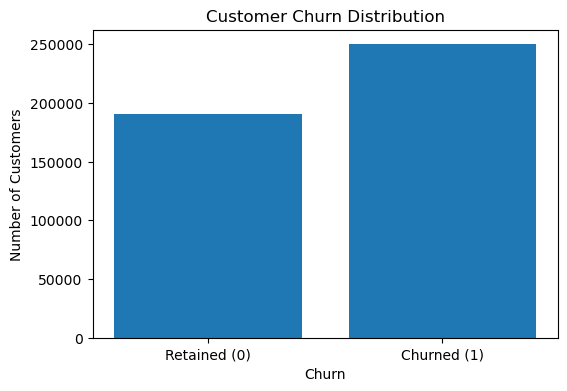

In [10]:
# 1) 종속변수 분포 계산
counts = df['Churn'].value_counts().sort_index()  # 0,1 순으로 정렬된 카운트
labels = ['Retained (0)', 'Churned (1)']          # x축 레이블

# 2) 시각화
plt.figure(figsize=(6, 4))
plt.bar(labels, counts)
plt.title('Customer Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Number of Customers')
plt.show()

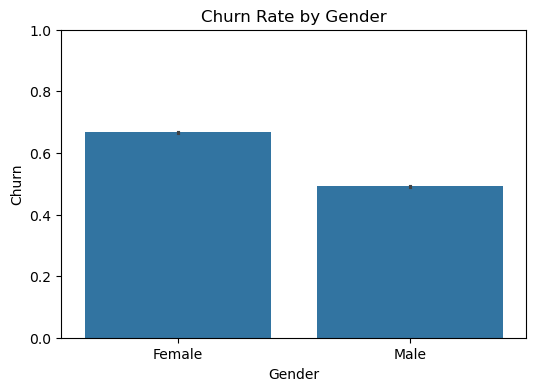

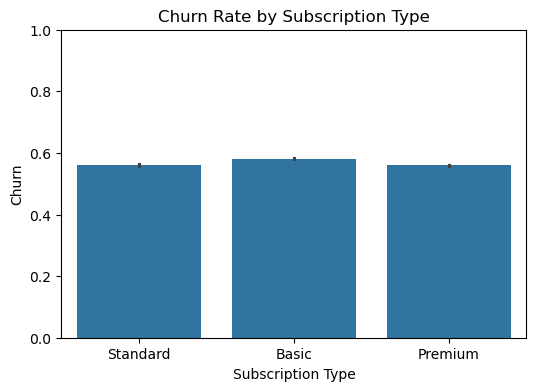

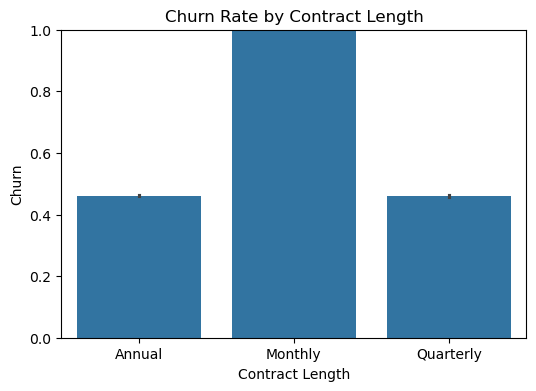

In [11]:
# - 범주형 변수별 이탈률  
for col in ['Gender','Subscription Type','Contract Length']:
    plt.figure(figsize=(6,4))
    sns.barplot(data=df, x=col, y='Churn')
    plt.title(f'Churn Rate by {col}')
    plt.ylim(0,1)
    plt.show()

In [12]:
df['Churn'].value_counts()

Churn
1.0    249999
0.0    190833
Name: count, dtype: int64

### **4-5 독립변수(설명변수) 데이터 확인**
#### 4-5.1 CustomerID : 고객 고유 ID

In [13]:
# CustomerID 중복 확인
dup_ids = df['CustomerID'][df['CustomerID'].duplicated()]
print(f"중복된 CustomerID 개수: {dup_ids.shape[0]}")
if not dup_ids.empty:
    print("중복된 ID들:", dup_ids.values)

중복된 CustomerID 개수: 0


#### 4-5.2 Age : 고객 연령  

In [14]:
print(df['Age'].min()) # 18
print(df['Age'].max()) # 65

18.0
65.0


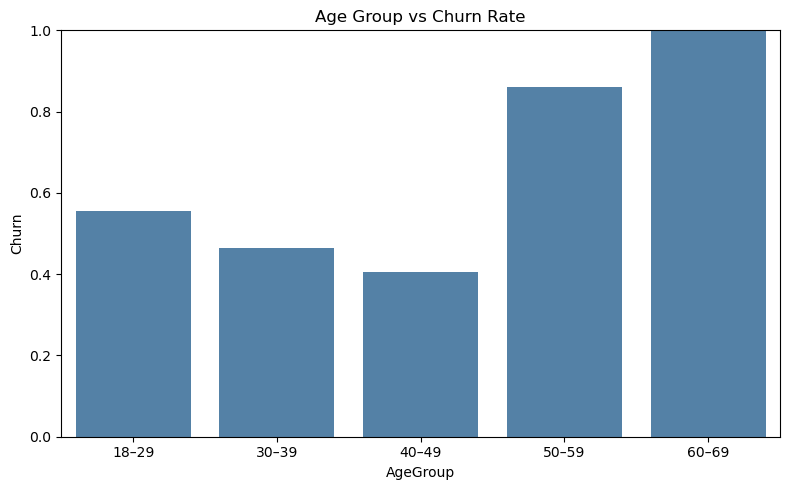

In [15]:
# 1) 나이를 구간으로 자르기
bins = [18, 30, 40, 50, 60, 70]
labels = ['18–29', '30–39', '40–49', '50–59', '60–69']
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels, right=False)

# 2) 그룹별 이탈률 계산
age_churn = df.groupby('AgeGroup', observed=True)['Churn'].mean().reset_index()

# 3) 막대그래프 그리기
plt.figure(figsize=(8,5))
sns.barplot(
    data=age_churn,
    x='AgeGroup', y='Churn',
    color='steelblue'      # 단일 색 지정
)
plt.title('Age Group vs Churn Rate')
plt.ylim(0,1)
plt.tight_layout()
plt.show()

-> 50–59세(≈86%), 60–69세(≈100%) 구간에선 이탈률이 급격히 높아짐.

#### 4-5.3 Gender : 성별 (`Male`, `Female`) 

<Axes: xlabel='Gender', ylabel='Churn'>

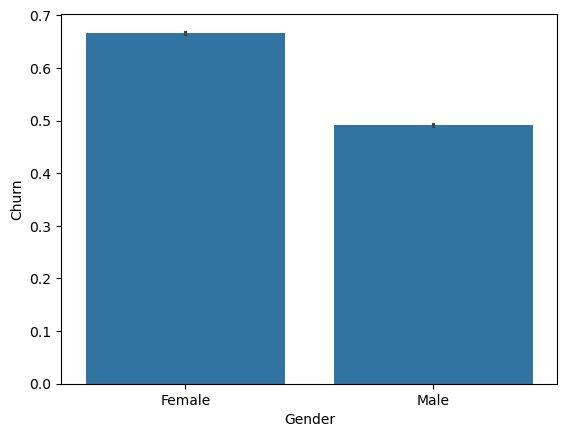

In [16]:
sns.barplot(data=df, x='Gender', y='Churn')

-> 여성의 이탈률이 약 67%로 남성(약 49%)보다 상당히 높음.

#### 4-5.4 Tenure : 가입 기간 (개월)

In [17]:
print(df['Tenure'].min()) # 1
print(df['Tenure'].max()) # 60

1.0
60.0


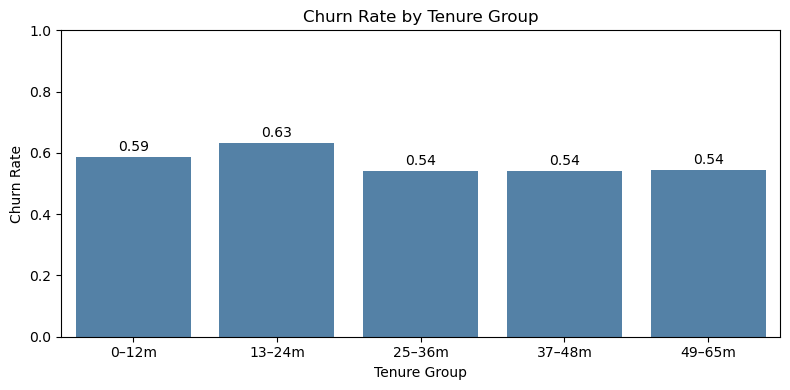

In [18]:
# 1) Tenure 구간 정의
bins = [0, 12, 24, 36, 48, 65]  
labels = ['0–12m','13–24m','25–36m','37–48m','49–65m']
df['TenureGroup'] = pd.cut(df['Tenure'], bins=bins, labels=labels, right=True, include_lowest=True)

# 2) 구간별 이탈률 계산
tenure_grp = df.groupby('TenureGroup',observed=False)['Churn'].mean().reset_index()

# 3) 막대그래프로 시각화
plt.figure(figsize=(8,4))
sns.barplot(data=tenure_grp, x='TenureGroup', y='Churn', color='steelblue')
plt.title('Churn Rate by Tenure Group')
plt.xlabel('Tenure Group')
plt.ylabel('Churn Rate')
plt.ylim(0,1)
for i, v in enumerate(tenure_grp['Churn']):
    plt.text(i, v + 0.02, f'{v:.2f}', ha='center')
plt.tight_layout()
plt.show()

-> 가입 후 13–24개월 구간에 가장 높은 이탈률(≈63%)이 나타남.

#### 4-5.5 Usage Frequency : 월별 평균 사용 횟수

In [19]:
print(df['Usage Frequency'].min()) # 1
print(df['Usage Frequency'].max()) # 30

1.0
30.0


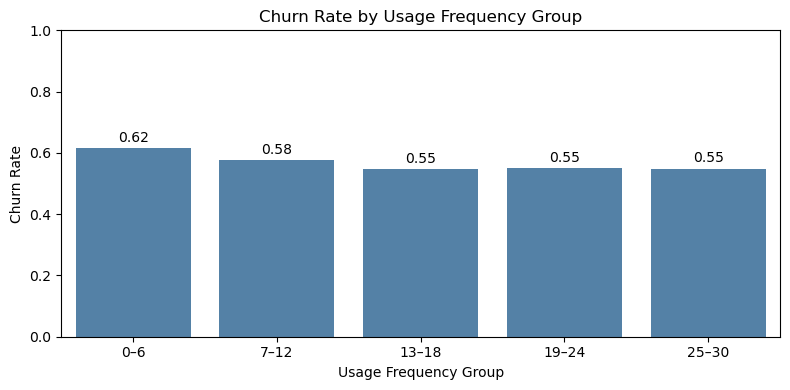

In [20]:
# 1) Usage Frequency 구간 정의
bins = [0, 6, 12, 18, 24, 30]  
labels = ['0–6','7–12','13–18','19–24','25–30']
df['Usage Frequency Group'] = pd.cut(df['Usage Frequency'], bins=bins, labels=labels, right=True, include_lowest=True)

# 2) 구간별 이탈률 계산
tenure_grp = df.groupby('Usage Frequency Group',observed=False)['Churn'].mean().reset_index()

# 3) 막대그래프로 시각화
plt.figure(figsize=(8,4))
sns.barplot(data=tenure_grp, x='Usage Frequency Group', y='Churn', color='steelblue')
plt.title('Churn Rate by Usage Frequency Group')
plt.xlabel('Usage Frequency Group')
plt.ylabel('Churn Rate')
plt.ylim(0,1)
for i, v in enumerate(tenure_grp['Churn']):
    plt.text(i, v + 0.02, f'{v:.2f}', ha='center')
plt.tight_layout()
plt.show()

-> 이용 횟수 0–6회(≈62%)에서 시작해 이용이 많아질수록(7–30회) 이탈률이 55% 선까지 떨어짐.

#### 4-5.6 Support Calls : 고객센터 문의 횟수

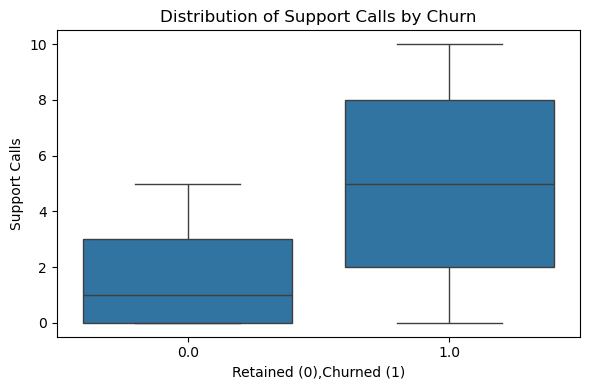

In [21]:
plt.figure(figsize=(6,4))
sns.boxplot(x='Churn', y='Support Calls', data=df)
plt.title('Distribution of Support Calls by Churn')
plt.xlabel('Retained (0),Churned (1)')
plt.ylabel('Support Calls')
plt.tight_layout()
plt.show()


-> 이탈고객(Churn=1)의 지원 콜 수 박스플롯 중앙값이 5회 정도, 유지고객(Churn=0)은 1회 정도임.

#### 4-5.7 Payment Delay : 연체 발생 횟수

In [22]:
print(df['Payment Delay'].min()) # 0
print(df['Payment Delay'].max()) # 30

0.0
30.0


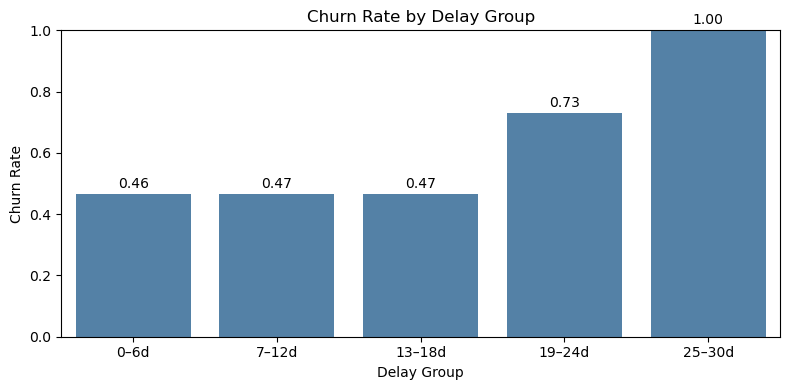

In [23]:
# 1) Usage Frequency 구간 정의
bins = [0, 6, 12, 18, 24, 30]  
labels = ['0–6d','7–12d','13–18d','19–24d','25–30d']
df['Delay Group'] = pd.cut(df['Payment Delay'], bins=bins, labels=labels, right=True, include_lowest=True)

# 2) 구간별 이탈률 계산
tenure_grp = df.groupby('Delay Group',observed=False)['Churn'].mean().reset_index()

# 3) 막대그래프로 시각화
plt.figure(figsize=(8,4))
sns.barplot(data=tenure_grp, x='Delay Group', y='Churn', color='steelblue')
plt.title('Churn Rate by Delay Group')
plt.xlabel('Delay Group')
plt.ylabel('Churn Rate')
plt.ylim(0,1)
for i, v in enumerate(tenure_grp['Churn']):
    plt.text(i, v + 0.02, f'{v:.2f}', ha='center')
plt.tight_layout()
plt.show()

-> 결제 지연이 19–24일(≈73%), 25–30일(≈100%)로 길어질수록 이탈률 상승함.

#### 4-5.8 Subscription Type : 가입 요금제 (`Basic`, `Standard`, `Premium`)

<Axes: xlabel='Subscription Type', ylabel='Churn'>

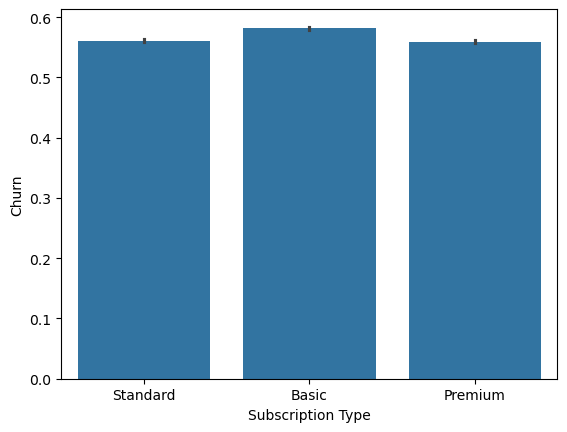

In [24]:
sns.barplot(data=df, x='Subscription Type', y='Churn')

-> 구독 등급별 이탈률은 전반적으로 비슷한 편이지만 Basic 고객의 이탈률이 다소 높은 것으로 나타남.

#### 4-5.9 Contract Length : 계약 기간 (`Month-to-Month`, `One Year`, `Two Year`)

<Axes: xlabel='Contract Length', ylabel='Churn'>

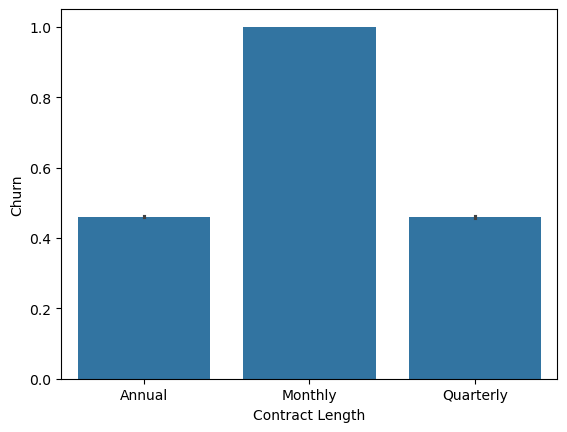

In [25]:
sns.barplot(data=df, x='Contract Length', y='Churn')

-> Annual·Quarterly 계약의 이탈률은 약 46%로 상대적으로 낮음. 

#### 4-5.10 Total Spend : 총 지출 금액  

In [26]:
print(df['Total Spend'].min()) # 100
print(df['Total Spend'].max()) # 1000

100.0
1000.0


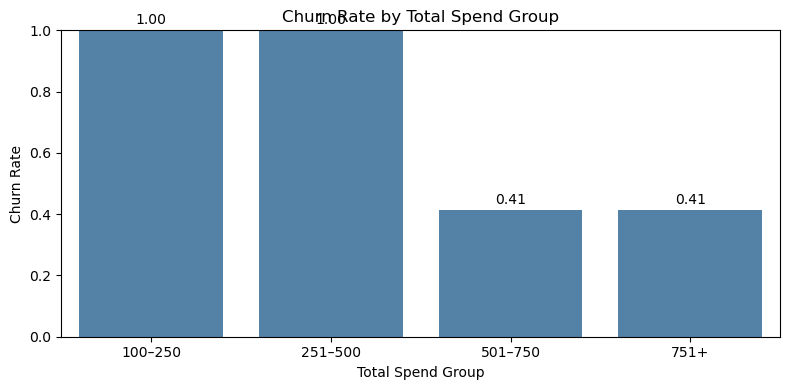

In [27]:
# 1) Total Spend 구간 정의 (예: 0–250, 250–500, 500–750, 750+)
bins = [100, 250, 500, 750, 1000]
labels = ['100–250','251–500','501–750','751+']
df['SpendGroup'] = pd.cut(
    df['Total Spend'],
    bins=bins,
    labels=labels,
    include_lowest=True,
    right=True
)

# 2) 구간별 평균 이탈률 계산
spend_grp = (df.groupby('SpendGroup', observed=True)['Churn'].mean().reset_index())

# 3) 막대그래프로 시각화
plt.figure(figsize=(8,4))
sns.barplot(
    data=spend_grp,
    x='SpendGroup', y='Churn',
    color='steelblue'
)
plt.title('Churn Rate by Total Spend Group')
plt.xlabel('Total Spend Group')
plt.ylabel('Churn Rate')
plt.ylim(0,1)
for i, v in enumerate(spend_grp['Churn']):
    plt.text(i, v + 0.02, f'{v:.2f}', ha='center')
plt.tight_layout()
plt.show()

-> 지출이 낮은 그룹(100–250, 251–500)은 이탈률이 100%로 매우 높음. 

#### 4-5.11 Last Interaction : 마지막 서비스 이용 후 지난 일수

In [28]:
print(df['Last Interaction'].min()) # 0
print(df['Last Interaction'].max()) # 30

1.0
30.0


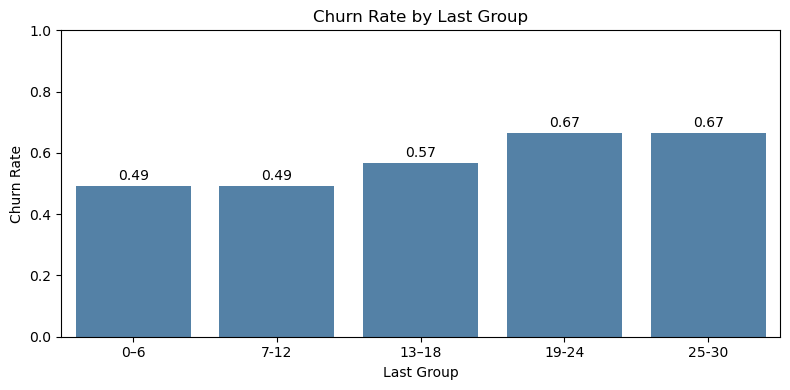

In [29]:
# 1) Last Interaction 구간 정의 (0, 6, 12, 18, 24, 30)
bins = [0, 6, 12, 18, 24, 30]
labels = ['0–6','7-12','13–18','19-24','25-30']
df['LastGroup'] = pd.cut(
    df['Last Interaction'],
    bins=bins,
    labels=labels,
    include_lowest=True,
    right=True
)

# 2) 구간별 평균 이탈률 계산
spend_grp = (df.groupby('LastGroup', observed=True)['Churn'].mean().reset_index())

# 3) 막대그래프로 시각화
plt.figure(figsize=(8,4))
sns.barplot(
    data=spend_grp,
    x='LastGroup', y='Churn',
    color='steelblue'
)
plt.title('Churn Rate by Last Group')
plt.xlabel('Last Group')
plt.ylabel('Churn Rate')
plt.ylim(0,1)
for i, v in enumerate(spend_grp['Churn']):
    plt.text(i, v + 0.02, f'{v:.2f}', ha='center')
plt.tight_layout()
plt.show()

-> 상호작용이 13–18일(≈57%), 19–24·25–30일(≈67%) 구간에선 이탈률이 점진적으로 상승함.

# **5. 파생변수 생성 (구간화)**

In [30]:
from sklearn.impute       import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose      import ColumnTransformer
from sklearn.pipeline     import Pipeline
from sklearn.ensemble     import RandomForestClassifier
from sklearn.model_selection import cross_val_score

In [31]:
# 1) 연령대 (AgeGroup)
bins_age  = [df['Age'].min()-1, 30, 40, 50, 60, df['Age'].max()+1]
labels_age= ['18–29','30–39','40–49','50–59','60+']
df['AgeGroup'] = pd.cut(df['Age'], bins=bins_age, labels=labels_age)
df_test ['AgeGroup'] = pd.cut(df_test['Age'],  bins=bins_age, labels=labels_age)

# 2) 지연일수 그룹 (Delay Group)
bins_delay  = [ -1,  6, 12, 18, 24, 30 ]
labels_delay= ['0–6d','7–12d','13–18d','19–24d','25–30d']
df['Delay Group'] = pd.cut(df['Payment Delay'], bins=bins_delay, labels=labels_delay)
df_test ['Delay Group'] = pd.cut(df_test ['Payment Delay'], bins=bins_delay, labels=labels_delay)

# 3) 지출액 그룹 (SpendGroup)
bins_spend  = [ df['Total Spend'].min()-1, 250, 500, 750, df['Total Spend'].max()+1 ]
labels_spend= ['100–250','251–500','501–750','751+']
df['SpendGroup'] = pd.cut(df['Total Spend'], bins=bins_spend, labels=labels_spend)
df_test ['SpendGroup'] = pd.cut(df_test ['Total Spend'], bins=bins_spend, labels=labels_spend)


# **6. 결측치·이상치 처리**
- **수치형 결측치 → 중앙값(median) 대체**  
 중앙값은 평균에 비해 outlier에 덜 민감하므로 이상치가 포함된 분포에서도 대체된 값이 데이터 특성을 잘 대표함.
- **범주형 결측치 → 최빈값(mode) 대체**  
 최빈값은 해당 변수에서 가장 빈도가 높은 값이므로 결측치를 채워도 기존 분포를 크게 왜곡하지 않음.
- **이상치(outlier) → IQR 캡핑(Capping)**  
 사분위간격(IQR; Q3−Q1)에 기반해 하한(Q1−1.5·IQR)과 상한(Q3+1.5·IQR)을 정하고 이를 벗어나는 값을 경계 값으로 제한하여 모델 학습의 안정성을 높임.

In [32]:
# train/test 결합
df['is_train'] = 1
df_test['is_train'] = 0
full = pd.concat([df, df_test], ignore_index=True)

In [33]:
# 결측치 처리
num_cols = full.select_dtypes(include=['int64','float64']).columns.drop(['Churn','is_train'], errors=False)
cat_cols = ['Gender','Subscription Type','Contract Length','AgeGroup','Delay Group','SpendGroup']

# 수치형: 중앙값(median) 대체
num_imp = SimpleImputer(strategy='median')
full[num_cols] = num_imp.fit_transform(full[num_cols])

# 범주형: 최빈값(mode) 대체
cat_imp = SimpleImputer(strategy='most_frequent')
full[cat_cols] = cat_imp.fit_transform(full[cat_cols])

In [34]:
# 3) 이상치(IQR) 캡핑 함수 정의 및 적용
def cap_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[col] = np.where(df[col] < lower, lower,
                       np.where(df[col] > upper, upper, df[col]))

for c in num_cols:
    cap_iqr(full, c)

# **7. 모델링(RandomForestClassifier)**
- 고객 이탈에 영향을 주는 여러 변수 간의 복잡한 비선형 패턴과 상호작용을 자동으로 학습.

- 나무 기반 모델은 특정 구간을 기준으로 분할하기 때문에 수치형 변수의 outlier가 전체 분류 경계에 미치는 영향을 완화할 수 있음.

- 결측치·범주형 처리 이후 바로 적용해도 안정적인 성능을 냄.

- 여러 개의 결정트리를 배깅하여 평균을 내므로 단일 트리 대비 과적합 위험을 줄여 줌.

#### **7.1 전처리 완료된 데이터를 train/test로 재분리**

In [35]:
train_proc = full[full['is_train']==1].drop(columns=['is_train'])
test_proc  = full[full['is_train']==0].drop(columns=['is_train','Churn'])

In [36]:
X_train = df.drop(columns=['CustomerID', 'Churn']) # CustomerID 는 예측에 쓸 의미 있는 정보가 아니므로 제거
Y_train = df['Churn']
X_test   = df_test.drop(columns=['CustomerID'])
test_ids = df_test['CustomerID']

#### **7.2 RandomForest 모델 학습**

In [38]:
# 1) 피처 구분
num_cols = [c for c in X_train.columns if X_train[c].dtype in ['int64','float64']]
cat_cols = ['Gender','Subscription Type','Contract Length',
            'AgeGroup','Delay Group','SpendGroup']

# 2) 전처리기 정의
preprocessor = ColumnTransformer([
    ('num', 'passthrough', num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), cat_cols)])

# 3) 파이프라인 생성
pipeline = Pipeline([
    ('prep', preprocessor),
    ('rf', RandomForestClassifier(
        n_estimators=100, random_state=42, n_jobs=-1))])

# 4) 교차검증
cv_scores = cross_val_score(
    pipeline, X_train, Y_train, cv=5, scoring='accuracy')

print(f"5-Fold CV Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

5-Fold CV Accuracy: 0.9972 ± 0.0001


In [39]:
# pipeline 을 학습
pipeline.fit(X_train, Y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  ['Age', 'Tenure',
                                                   'Usage Frequency',
                                                   'Support Calls',
                                                   'Payment Delay',
                                                   'Total Spend',
                                                   'Last Interaction',
                                                   'is_train']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['Gender',
                                                   'Subscription Type',
                                                   'Contract Length',
                                                   'AgeGroup', 'Delay Group',
                                                   'SpendGroup'])])),
                ('rf', RandomForestClassifier(n_jobs=-1, random_state=42))])

In [41]:
rf_model = pipeline.named_steps['rf']
print(rf_model)            # fitted model repr
rf_model.get_params()      # 모든 파라미터 확인

RandomForestClassifier(n_jobs=-1, random_state=42)


{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': -1,
 'oob_score': False,
 'random_state': 42,
 'verbose': 0,
 'warm_start': False}

# **8. 최종 학습 & 예측**

In [42]:
# pipeline에 학습 결과가 담겨 있으므로 pipeline.predict를 사용
Y_pred = pipeline.predict(X_test)

# 결과를 원래 형태('Yes'/'No')로 복원
output = pd.DataFrame({
    'customerID': test_ids,
    'Churn': np.where(Y_pred==1, 'Yes', 'No')
})

In [43]:
output.to_csv('test.csv', index=False) 
print("✅ test.csv 샘플")
print(output.head())

✅ test.csv 샘플
   customerID Churn
0           1   Yes
1           2   Yes
2           3   Yes
3           4   Yes
4           5   Yes
